In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import os

drive_path = '/content/gdrive/My Drive/'
project_folder = os.path.join(drive_path, 'Skin Cancer Detection Using CNN')

train_folder = os.path.join(project_folder, 'Train')
test_folder = os.path.join(project_folder, 'Test')

print(f"Listing contents of Train folder: {train_folder}")
if os.path.exists(train_folder):
    print(os.listdir(train_folder))
else:
    print(f"Train folder not found at: {train_folder}")

print(f"\nListing contents of Test folder: {test_folder}")
if os.path.exists(test_folder):
    print(os.listdir(test_folder))
else:
    print(f"Test folder not found at: {test_folder}")

Listing contents of Train folder: /content/gdrive/My Drive/Skin Cancer Detection Using CNN/Train
['vascular lesion', 'squamous cell carcinoma', 'pigmented benign keratosis', 'melanoma', 'nevus', 'actinic keratosis', 'dermatofibroma', 'seborrheic keratosis', 'basal cell carcinoma']

Listing contents of Test folder: /content/gdrive/My Drive/Skin Cancer Detection Using CNN/Test
['squamous cell carcinoma', 'vascular lesion', 'seborrheic keratosis', 'pigmented benign keratosis', 'actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus']


In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Rescaling,Conv2D, MaxPooling2D,
    Flatten, Dense, Dropout
)
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

In [9]:
data_dir = "/content/gdrive/MyDrive/Skin Cancer Detection Using CNN/Train"
data_dir

'/content/gdrive/MyDrive/Skin Cancer Detection Using CNN/Train'

In [10]:
train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

Found 2252 files belonging to 9 classes.
Using 1802 files for training.
Found 2252 files belonging to 9 classes.
Using 450 files for validation.


In [11]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [12]:
val_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [13]:
class_names = train_ds.class_names
class_names

['actinic keratosis',
 'basal cell carcinoma',
 'dermatofibroma',
 'melanoma',
 'nevus',
 'pigmented benign keratosis',
 'seborrheic keratosis',
 'squamous cell carcinoma',
 'vascular lesion']

In [14]:
layers.Lambda(tf.keras.applications.efficientnet.preprocess_input),


(<Lambda name=lambda, built=False>,)

In [15]:
normalization_layer = Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))

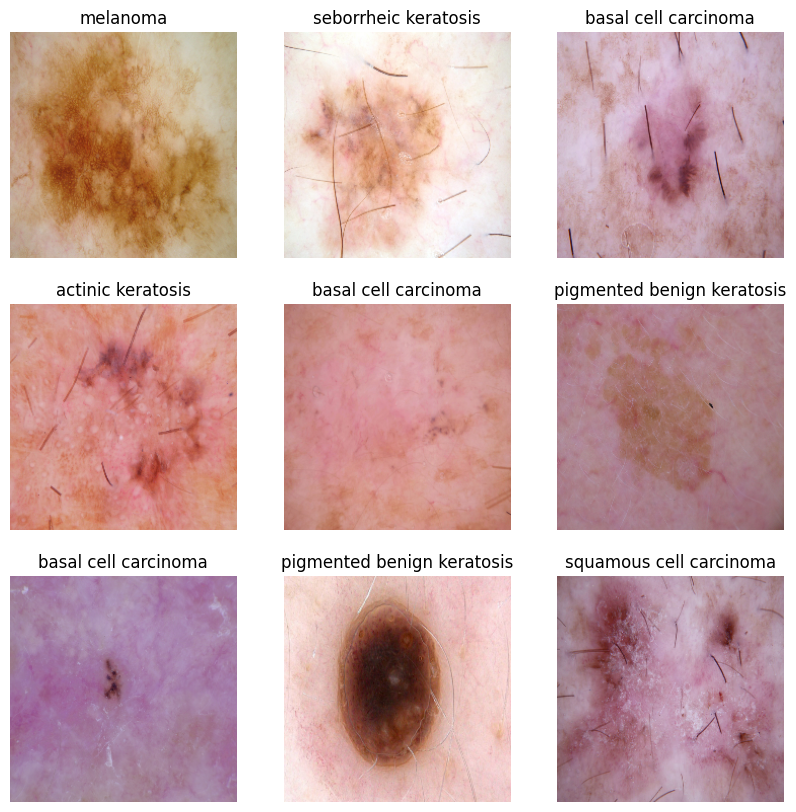

In [16]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title(class_names[int(labels[i])])
    plt.axis("off")

plt.show()

In [17]:
augment = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2)
])
augment


<Sequential name=sequential, built=False>

In [18]:
train_ds

<_MapDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [19]:
val_ds

<_MapDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [20]:
model = Sequential([

    layers.Input(shape=(224, 224, 3)),

    augment,


    Conv2D(32, 3, activation="relu" ), # 32 kernal ( filter ( 3*3 ))
    MaxPooling2D(),

    Conv2D(64, 3, activation="relu"),
    MaxPooling2D(),

    Conv2D(128, 3, activation="relu"),
    MaxPooling2D(),


    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(9, activation="softmax")
])


In [21]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,121 (42.61 MB)

 Trainable params: 11,170,121 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ModelCheckpoint("/kaggle/working/best_model.keras", save_best_only=True, monitor="val_loss")
]


In [25]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 694s 12s/step - accuracy: 0.1992 - loss: 2.1793 - val_accuracy: 0.2378 - val_loss: 1.9422 - learning_rate: 0.0010
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 355ms/step - accuracy: 0.2597 - loss: 1.9640 - val_accuracy: 0.3667 - val_loss: 1.7940 - learning_rate: 0.0010
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 379ms/step - accuracy: 0.2880 - loss: 1.8890 - val_accuracy: 0.3889 - val_loss: 1.7392 - learning_rate: 0.0010
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 356ms/step - accuracy: 0.3374 - loss: 1.8159 - val_accuracy: 0.2622 - val_loss: 1.8701 - learning_rate: 0.0010
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 23s 409ms/step - accuracy: 0.3030 - loss: 1.8568 - val_accuracy: 0.3889 - val_loss: 1.6578 - learning_rate: 0.0010
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 374ms/step - accuracy: 0.2947 - loss: 1.8502 - val_accuracy: 0.3600 - val_loss: 1.6918 - learning_rate: 0.0010
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 364ms/step - accuracy: 0.3929 - loss: 1.7

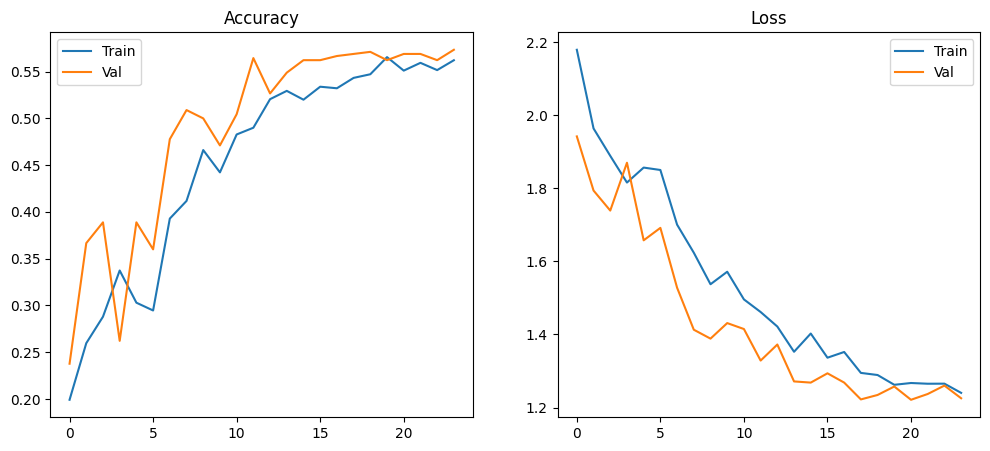

In [26]:
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.show()


In [27]:
test_loss, test_acc = model.evaluate(val_ds)
print("Test Accuracy:", test_acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 231ms/step - accuracy: 0.5689 - loss: 1.2212
Test Accuracy: 0.5688889026641846


In [30]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=1)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


In [31]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.36      0.55      0.43        66
            dermatofibroma       0.00      0.00      0.00        18
                  melanoma       0.66      0.80      0.72        98
                     nevus       0.69      0.54      0.61        74
pigmented benign keratosis       0.55      0.79      0.65        97
      seborrheic keratosis       0.00      0.00      0.00        14
   squamous cell carcinoma       0.00      0.00      0.00        34
           vascular lesion       0.81      0.76      0.78        33

                  accuracy                           0.57       450
                 macro avg       0.34      0.38      0.35       450
              weighted avg       0.49      0.57      0.52       450



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
import os
import json
import tensorflow as tf

os.makedirs("/kaggle/working/streamlit_tflite", exist_ok=True)


best_model = tf.keras.models.load_model(
    "/kaggle/working/best_model.keras",
    compile=False
)


converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()


with open("/kaggle/working/streamlit_tflite/model.tflite", "wb") as f:
    f.write(tflite_model)


with open("/kaggle/working/streamlit_tflite/class_names.json", "w") as f:
    json.dump(class_names, f)

print(os.listdir("/kaggle/working/streamlit_tflite"))

Saved artifact at '/tmp/tmpi_c2otj9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  133872938542544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133872938541392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133872938544272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133872938538704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133872938542736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133872938541584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133872938539856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133872938544080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133872938542928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133872938540816: TensorSpec(shape=(), dtype=tf.resource, name=None)
['model.tflite', 

In [33]:
import os
import json
import tensorflow as tf

# Save the model after the last epoch
model.save("/kaggle/working/final_model.keras")

# Convert the final model to TFLite
converter_final = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_final_model = converter_final.convert()

# Ensure the directory exists
os.makedirs("/kaggle/working/streamlit_tflite", exist_ok=True)

# Save the TFLite final model
with open("/kaggle/working/streamlit_tflite/final_model.tflite", "wb") as f:
    f.write(tflite_final_model)

# Save class names again (already done, but good for consistency if this is a new run)
with open("/kaggle/working/streamlit_tflite/class_names.json", "w") as f:
    json.dump(class_names, f)

print(f"Current model saved as: /kaggle/working/final_model.keras")
print(f"Current model TFLite version saved as: /kaggle/working/streamlit_tflite/final_model.tflite")
print(f"Files in /kaggle/working/streamlit_tflite: {os.listdir("/kaggle/working/streamlit_tflite")}")

Saved artifact at '/tmp/tmp50zdqquy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  133873530167248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133873530168016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133873530169552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133873530168784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133873530169744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133873530170512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133873530171472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133873530170704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133873530171856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133873530171664: TensorSpec(shape=(), dtype=tf.resource, name=None)
Current model sa